<a href="https://colab.research.google.com/github/LakshmiSingh789/AppMars/blob/main/notebooks/CNN%20Metal%20Defect%20Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Convolutional Neural Networks with PyTorch — Hands-On Session
## Metal Surface Defect Classification (GC10-DET Dataset, 6 Classes)

---

### Session Overview

In this hands-on session we build a **Convolutional Neural Network (CNN)** from scratch in PyTorch and train it end-to-end to classify **metal surface defect images** into **6 categories**, using the GC10-DET dataset from Kaggle.

### Learning Objectives

1. Download and **explore a real-world image dataset**, and curate it by selecting the classes that have enough data to be learnable
2. Apply the three core CNN operations:
   - **Convolution** (`nn.Conv2d`) — feature extraction with learnable filters
   - **Activation** (`nn.ReLU`) — non-linearity
   - **Pooling** (`nn.MaxPool2d`) — spatial downsampling
3. Use modern CNN components: **BatchNorm** and **Global Average Pooling**
4. Handle **class imbalance** with a weighted loss and **label smoothing**
5. Write the complete **PyTorch training loop** with a cosine learning-rate schedule and early stopping
6. Evaluate honestly with a **confusion matrix** and per-class precision / recall / F1
7. **Visualize feature maps** to see what the CNN learned

### About the Dataset (GC10-DET)

Grayscale photographs (2048×1000 px) of metal sheet surfaces from a real production line. Each image shows one defect type. We will keep the **6 defect classes with the most images**:

| Defect | Cause |
|--------|-------|
| Crescent Gap | Half-circle shaped cutting defects |
| Inclusion | Foreign particles pressed into the surface |
| Punching Hole | Unwanted punched holes from mechanical failure |
| Silk Spot | Wave-like plaque from uneven roller pressure |
| Water Spot | Drying spots during production |
| Welding Line | Line left when steel strips are joined |

>  **Before you start:** enable the GPU — **Runtime → Change runtime type → T4 GPU**.

---

## Step 1 — Environment Setup

**What we are doing:** Installing `kagglehub` (the Kaggle dataset downloader), importing all libraries used in this session, fixing all random seeds, and selecting the computation device.

**Why we are doing it:**
- `torch` provides tensors and autograd (automatic differentiation — it will compute all gradients for us), `torch.nn` provides layers and loss functions, `torchvision` provides `ImageFolder` and image `transforms`, `DataLoader` handles batching, and sklearn provides the evaluation metrics.
- Fixing the seeds makes every run reproducible — the same split and the same results every time, which is essential for a classroom demo.
- PyTorch requires us to explicitly place the model and every batch on the GPU with `.to(device)`; nothing moves automatically, so we detect and store the device once here.

In [1]:
!pip install -q kagglehub

import os
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import datasets, transforms
from torchvision.utils import make_grid

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch version :", torch.__version__)
print("Using device    :", device)
if device.type == "cuda":
    print("GPU             :", torch.cuda.get_device_name(0))

PyTorch version : 2.11.0+cu128
Using device    : cuda
GPU             : Tesla T4


## Step 2 — Download the Dataset

**What we are doing:** Downloading the *Defects Class and Location* (GC10-DET) dataset from Kaggle using `kagglehub`.

**Why we are doing it:** `kagglehub` fetches the latest version of a public dataset with a single call and **no API key**. The files are cached locally, so re-running this cell will not re-download the ~900 MB archive — it just returns the cached path.

In [2]:
import kagglehub

path = kagglehub.dataset_download("zhangyunsheng/defects-class-and-location")
print("Path to dataset files:", path)

100%|██████████| 923M/923M [00:25<00:00, 38.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/zhangyunsheng/defects-class-and-location/versions/1


## Step 3 — Explore the Directory Structure

**What we are doing:** Walking through the downloaded folder tree and printing every directory together with how many image files and how many XML files it contains.

**Why we are doing it:** *Always look at your data before modeling it.* Real datasets are messy — we must confirm three things before writing any model code:
1. Images are organized **one folder per class** (the layout `torchvision.datasets.ImageFolder` expects).
2. There is a `label/` folder containing **XML bounding-box annotations** meant for object *detection* — our task is *classification*, so this folder must be excluded, otherwise it would be wrongly treated as an extra class.
3. A first feel for how many images each class has.

In [3]:
IMG_EXTS = ('.jpg', '.jpeg', '.png', '.bmp')

print("Directory tree of the downloaded dataset:")
print("=" * 60)
for root, dirs, files in os.walk(path):
    depth = root.replace(path, '').count(os.sep)
    indent = '    ' * depth
    n_imgs = sum(1 for f in files if f.lower().endswith(IMG_EXTS))
    n_xml = sum(1 for f in files if f.lower().endswith('.xml'))
    label = os.path.basename(root) if depth > 0 else '(dataset root)'
    print(f"{indent}{label}/  ->  {n_imgs} images, {n_xml} xml files")

Directory tree of the downloaded dataset:
(dataset root)/  ->  0 images, 0 xml files
    label/  ->  0 images, 0 xml files
        label/  ->  0 images, 2280 xml files
    images/  ->  0 images, 0 xml files
        images/  ->  0 images, 0 xml files
            oil_spot/  ->  204 images, 0 xml files
            waist folding/  ->  146 images, 0 xml files
            water_spot/  ->  289 images, 0 xml files
            rolled_pit/  ->  31 images, 0 xml files
            crescent_gap/  ->  226 images, 0 xml files
            crease/  ->  52 images, 0 xml files
            welding_line/  ->  273 images, 0 xml files
            punching_hole/  ->  219 images, 0 xml files
            inclusion/  ->  216 images, 0 xml files
            silk_spot/  ->  650 images, 0 xml files


## Step 4 — Count Images per Class and Select the Best 6 Classes

**What we are doing:** Counting the images inside every class folder (skipping the annotation folder), sorting the classes by size, and keeping only the **6 classes with the most images**.

**Why we are doing it:** A neural network needs enough examples per class to learn a visual concept. The smallest classes in this dataset have only a few dozen images — after a 70/15/15 split that leaves a handful of test images, which is both unlearnable and statistically meaningless to evaluate. Keeping such classes doesn't just fail *those* classes: their wrong predictions also steal accuracy from the good ones. **Data curation — deciding what is learnable with the data at hand — is a core ML skill**, and here we let the numbers make the decision for us.

In [4]:
class_counts = {}
class_paths = {}
for root, dirs, files in os.walk(path):
    imgs = [f for f in files if f.lower().endswith(IMG_EXTS)]
    folder_name = os.path.basename(root).strip()
    if len(imgs) > 0 and 'lab' not in folder_name.lower():
        clean = folder_name.replace(' ', '_').lower()
        class_counts[clean] = len(imgs)
        class_paths[clean] = root

counts_df = (pd.DataFrame({"class": list(class_counts.keys()),
                           "num_images": list(class_counts.values())})
             .sort_values("num_images", ascending=False).reset_index(drop=True))
print("All classes, sorted by size:")
print(counts_df.to_string(index=True))

N_KEEP = 6
selected_classes = counts_df.head(N_KEEP)["class"].tolist()
dropped_classes = counts_df.tail(len(counts_df) - N_KEEP)["class"].tolist()

print(f"\nKEEPING the {N_KEEP} largest classes : {selected_classes}")
print(f"DROPPING (too few samples)      : {dropped_classes}")
print(f"\nImages kept: {counts_df.head(N_KEEP)['num_images'].sum()} of {counts_df['num_images'].sum()} total")

All classes, sorted by size:
           class  num_images
0      silk_spot         650
1     water_spot         289
2   welding_line         273
3   crescent_gap         226
4  punching_hole         219
5      inclusion         216
6       oil_spot         204
7  waist_folding         146
8         crease          52
9     rolled_pit          31

KEEPING the 6 largest classes : ['silk_spot', 'water_spot', 'welding_line', 'crescent_gap', 'punching_hole', 'inclusion']
DROPPING (too few samples)      : ['oil_spot', 'waist_folding', 'crease', 'rolled_pit']

Images kept: 1873 of 2306 total


## Step 5 — Build a Clean 6-Class Working Copy

**What we are doing:** Creating a fresh directory `/content/defect_dataset/` and symlinking only the 6 selected class folders into it, in the classic folder-per-class layout:

```
/content/defect_dataset/
├── crescent_gap/    ├── punching_hole/    ├── water_spot/
├── inclusion/       ├── silk_spot/        └── welding_line/
```

**Why we are doing it:** `ImageFolder` treats **every** sub-folder as a class. Pointing it at the raw download would contaminate the labels with the annotation folder and the dropped classes. A clean directory guarantees correct labels. We use **symlinks** instead of copies because they are instant and duplicate no data on disk. Folder names are also sanitized (spaces → underscores, lowercase) so class names are consistent everywhere.

In [5]:
WORK_DIR = "/content/defect_dataset"
if os.path.exists(WORK_DIR):
    shutil.rmtree(WORK_DIR)
os.makedirs(WORK_DIR)

for cname in selected_classes:
    src = class_paths[cname]
    dst = os.path.join(WORK_DIR, cname)
    os.makedirs(dst, exist_ok=True)
    for f in os.listdir(src):
        if f.lower().endswith(IMG_EXTS):
            os.symlink(os.path.join(src, f), os.path.join(dst, f))

print("Clean 6-class dataset ready:", sorted(os.listdir(WORK_DIR)))

Clean 6-class dataset ready: ['crescent_gap', 'inclusion', 'punching_hole', 'silk_spot', 'water_spot', 'welding_line']


## Step 6 — Dataset Summary Table and Class Distribution

**What we are doing:** Building a pandas table with, for each class: the number of images, one example filename, the image resolution, and the PIL mode; then plotting the class distribution as a bar chart.

**Why we are doing it:** One glance answers *how big is the data, what resolution are the photos, and is the data balanced?* Two observations matter for our later design decisions:
1. The photos are **2048×1000 px** — large images full of fine texture, so the input resolution we resize to must be high enough to preserve that texture.
2. The distribution is **imbalanced** (the largest class has roughly 3× the images of the smallest). If we ignored this, the model could favor the big class — we will counter it with a **class-weighted loss** later.

        class  num_images                example_file image_size (WxH) PIL mode
 crescent_gap         226 img_01_3402617700_00001.jpg        2048x1000        L
    inclusion         216  img_01_425391700_00025.jpg        2048x1000        L
punching_hole         219  img_02_425501900_00017.jpg        2048x1000        L
    silk_spot         650 img_01_3436814600_00259.jpg        2048x1000        L
   water_spot         289  img_01_424995500_00255.jpg        2048x1000        L
 welding_line         273  img_01_425382400_00001.jpg        2048x1000        L
        TOTAL        1873                                                      


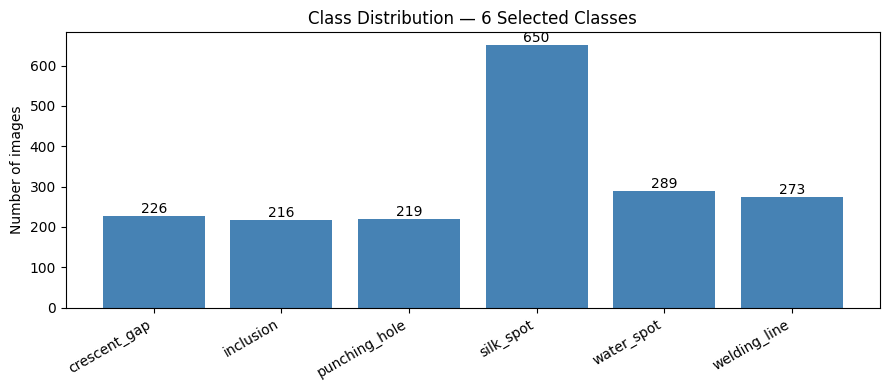

In [6]:
rows = []
for cname in sorted(os.listdir(WORK_DIR)):
    files = sorted(os.listdir(os.path.join(WORK_DIR, cname)))
    with Image.open(os.path.join(WORK_DIR, cname, files[0])) as im:
        size, mode = im.size, im.mode
    rows.append({"class": cname, "num_images": len(files),
                 "example_file": files[0],
                 "image_size (WxH)": f"{size[0]}x{size[1]}", "PIL mode": mode})
df_summary = pd.DataFrame(rows)
df_summary.loc[len(df_summary)] = ["TOTAL", df_summary["num_images"].sum(), "", "", ""]
print(df_summary.to_string(index=False))

plt.figure(figsize=(9, 4))
d = df_summary[df_summary["class"] != "TOTAL"]
bars = plt.bar(d["class"], d["num_images"], color='steelblue')
plt.bar_label(bars)
plt.xticks(rotation=30, ha='right')
plt.ylabel("Number of images")
plt.title("Class Distribution — 6 Selected Classes")
plt.tight_layout()
plt.show()

## Step 7 — Show the Actual Images (3 per class)

**What we are doing:** Displaying three randomly chosen raw images from each of the 6 classes — exactly the data we are about to model.

**Why we are doing it:** Visual inspection builds intuition about task difficulty *before* training. Notice that *punching_hole* and *crescent_gap* have distinctive shapes (likely easy classes), while *silk_spot* and *water_spot* differ only by subtle texture (likely hard classes). Keep this intuition in mind — we will verify it against the confusion matrix at the end of the session.

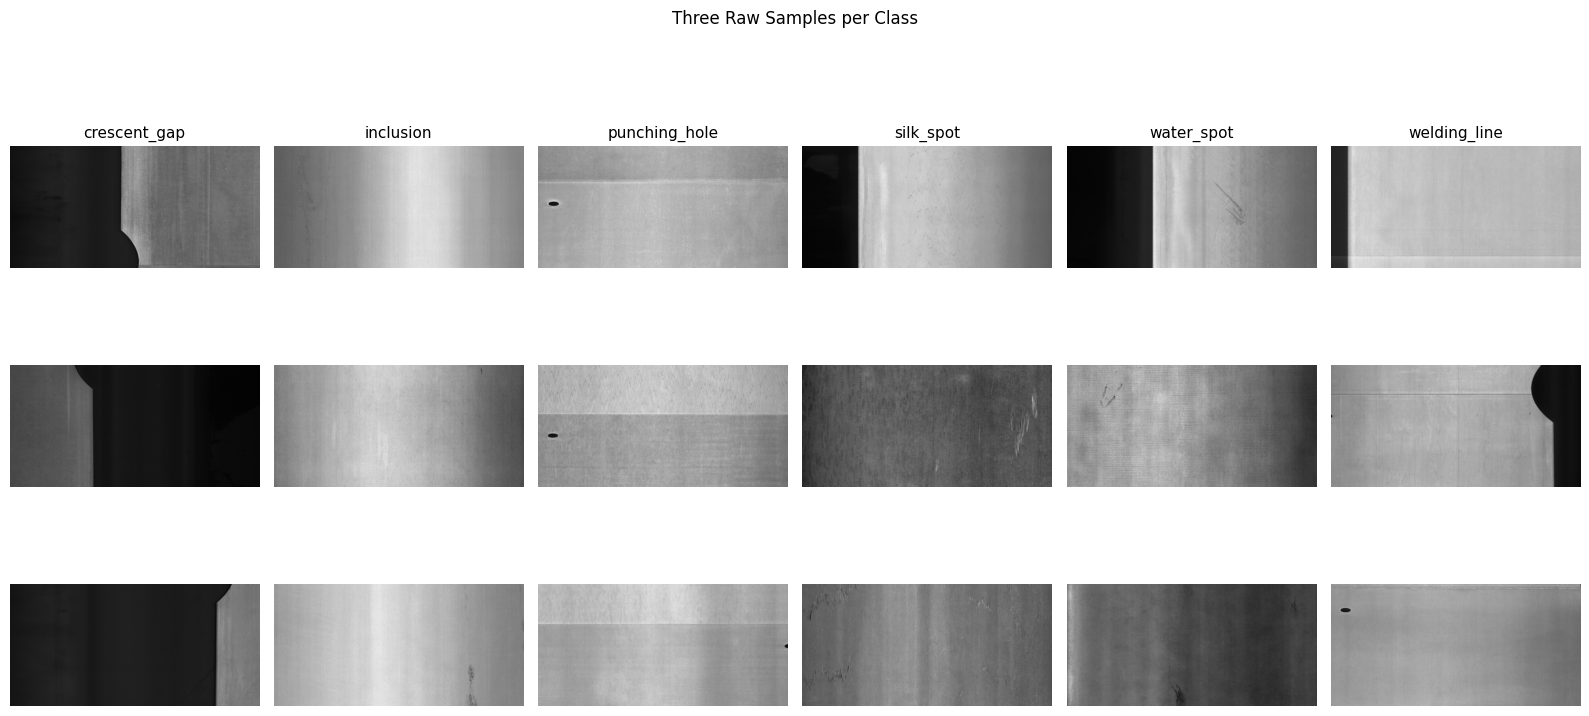

In [7]:
fig, axes = plt.subplots(3, 6, figsize=(16, 8))
for j, cname in enumerate(sorted(os.listdir(WORK_DIR))):
    img_files = random.sample(os.listdir(os.path.join(WORK_DIR, cname)), 3)
    for i in range(3):
        img = Image.open(os.path.join(WORK_DIR, cname, img_files[i]))
        axes[i, j].imshow(img, cmap='gray')
        axes[i, j].axis('off')
        if i == 0:
            axes[i, j].set_title(cname, fontsize=11)
plt.suptitle("Three Raw Samples per Class", y=1.00)
plt.tight_layout()
plt.show()

## Step 8 — Transforms: From Image Files to Normalized Tensors

**What we are doing:** Defining two transform pipelines — one for **training** (with random augmentation) and one for **validation/test** (without augmentation).

**Why we are doing it — transform by transform:**

| Transform | Effect | Why |
|-----------|--------|-----|
| `Grayscale(1)` | Force 1 channel | Metal photos carry no useful color → 3× fewer input values, no information lost |
| `Resize((224, 224))` | Fixed input size | CNNs need a constant shape; 224 px is high enough to preserve the fine defect texture of the 2048×1000 originals |
| `RandomHorizontalFlip` / `RandomVerticalFlip` | Mirrors (train only) | A defect is still the same defect when mirrored |
| `RandomRotation(10°)` | Small rotations (train only) | Defects occur at arbitrary orientations |
| `ColorJitter(0.2, 0.2)` | Brightness/contrast jitter (train only) | Industrial lighting varies between photos |
| `ToTensor()` | PIL image → FloatTensor, 0–255 → 0–1, HWC → **CHW** | PyTorch convention: channels first |
| `Normalize(0.5, 0.5)` | Rescale to ≈ [-1, 1] | Zero-centered inputs make gradient descent converge faster |

**Why augment only the training data?** Augmentation shows the model a slightly different version of every image each epoch, so it cannot memorize exact pictures and is forced to learn the *general pattern* of each defect — our cheapest weapon against **overfitting**. Validation and test images must stay untouched so the evaluation remains honest. Augmentation is kept moderate on purpose: too-aggressive transforms can destroy the subtle textures that distinguish similar defects.

In [8]:
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

print("Transforms defined, input resolution:", IMG_SIZE, "px")

Transforms defined, input resolution: 224 px


## Step 9 — Datasets, Stratified 70/15/15 Split, and DataLoaders

**What we are doing:** Creating **two** `ImageFolder` views of the same folder — one with the training transform, one with the evaluation transform — then splitting the image indices into **train (70 %) / validation (15 %) / test (15 %)**, *stratified by class*, and wrapping each subset in a `DataLoader`.

**Why we are doing it:**
- `ImageFolder` is *lazy*: it stores only `(filepath, label)` pairs and loads + transforms each image on demand — nothing is held in memory.
- **The two-view trick:** training indices go into the augmented view, validation/test indices into the clean view. Same underlying files, but only training images get augmented.
- **Stratified split:** with imbalanced classes, a purely random split could distort the class mix in the small validation/test sets; stratification keeps the class proportions identical in all three splits.
- **The three splits have distinct jobs:** train = weights are updated on it; validation = monitored every epoch to pick the best checkpoint (never trains); test = touched **only once** at the very end for the honest final score.
- `DataLoader` with `batch_size=32` gives mini-batch gradient descent; `shuffle=True` only for training so every epoch sees a fresh order; `num_workers=2` loads images in parallel on the CPU so the GPU never waits.

In [9]:
full_train_view = datasets.ImageFolder(WORK_DIR, transform=train_transform)
full_eval_view = datasets.ImageFolder(WORK_DIR, transform=eval_transform)

class_names = full_train_view.classes
NUM_CLASSES = len(class_names)
all_labels = np.array([lbl for _, lbl in full_train_view.samples])

print(f"Total images : {len(full_train_view)}")
print(f"Classes ({NUM_CLASSES}) : {class_names}")
print(f"Class -> index mapping: {full_train_view.class_to_idx}")

idx = np.arange(len(full_train_view))
train_idx, temp_idx = train_test_split(idx, test_size=0.30,
                                       stratify=all_labels, random_state=SEED)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50,
                                     stratify=all_labels[temp_idx], random_state=SEED)

train_ds = Subset(full_train_view, train_idx)
val_ds = Subset(full_eval_view, val_idx)
test_ds = Subset(full_eval_view, test_idx)

print(f"\nTrain : {len(train_ds)} | Val : {len(val_ds)} | Test : {len(test_ds)}")

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True)

print("DataLoaders ready")

Total images : 1873
Classes (6) : ['crescent_gap', 'inclusion', 'punching_hole', 'silk_spot', 'water_spot', 'welding_line']
Class -> index mapping: {'crescent_gap': 0, 'inclusion': 1, 'punching_hole': 2, 'silk_spot': 3, 'water_spot': 4, 'welding_line': 5}

Train : 1311 | Val : 281 | Test : 281
DataLoaders ready


## Step 10 — Inspect One Sample and One Batch

**What we are doing:** Printing the first few `(filepath, label)` pairs stored inside `ImageFolder`, then pulling one transformed sample and one full batch and printing their **shapes, dtypes, and value ranges**.

**Why we are doing it:** This is the moment the abstraction becomes concrete — a JPEG on disk has become a `FloatTensor` of shape `[1, 224, 224]` = (channels, height, width; PyTorch is channels-**first**), with values ≈ [-1, 1] after normalization. A batch stacks 32 of these into `[32, 1, 224, 224]` with one integer label per image. Verifying shapes here catches data-pipeline bugs *before* they turn into cryptic model errors.

In [10]:
print("First 5 (filepath, label) entries stored by ImageFolder:")
for fp, lbl in full_train_view.samples[:5]:
    print(f"  label={lbl} ({class_names[lbl]:<15s})  {os.path.basename(fp)}")

img_t, label = train_ds[0]
print("\nOne transformed training sample:")
print(f"  shape  : {tuple(img_t.shape)}")
print(f"  dtype  : {img_t.dtype}")
print(f"  range  : [{img_t.min():.3f}, {img_t.max():.3f}]")
print(f"  label  : {label}  ->  class '{class_names[label]}'")

images, labels = next(iter(train_loader))
print(f"\nImage batch shape : {tuple(images.shape)}")
print(f"Label batch shape : {tuple(labels.shape)}")

First 5 (filepath, label) entries stored by ImageFolder:
  label=0 (crescent_gap   )  img_01_3402617700_00001.jpg
  label=0 (crescent_gap   )  img_01_3402617700_01009.jpg
  label=0 (crescent_gap   )  img_01_424799300_01133.jpg
  label=0 (crescent_gap   )  img_01_424799600_00001.jpg
  label=0 (crescent_gap   )  img_01_424799600_00002.jpg

One transformed training sample:
  shape  : (1, 224, 224)
  dtype  : torch.float32
  range  : [-1.000, 0.161]
  label  : 1  ->  class 'inclusion'

Image batch shape : (32, 1, 224, 224)
Label batch shape : (32,)


## Step 11 — Show a Full Training Batch (as the network sees it)

**What we are doing:** Un-normalizing one batch of augmented training images (so they display correctly), tiling 24 of them into a single grid with `make_grid`, and printing the class label of each image row by row.

**Why we are doing it:** This grid is **literally the tensor entering the CNN**. Compare it with the raw images from Step 7 — you can spot the random flips, rotations, and brightness changes injected by the augmentation pipeline. Seeing the model's actual input demystifies the whole data pipeline for students.

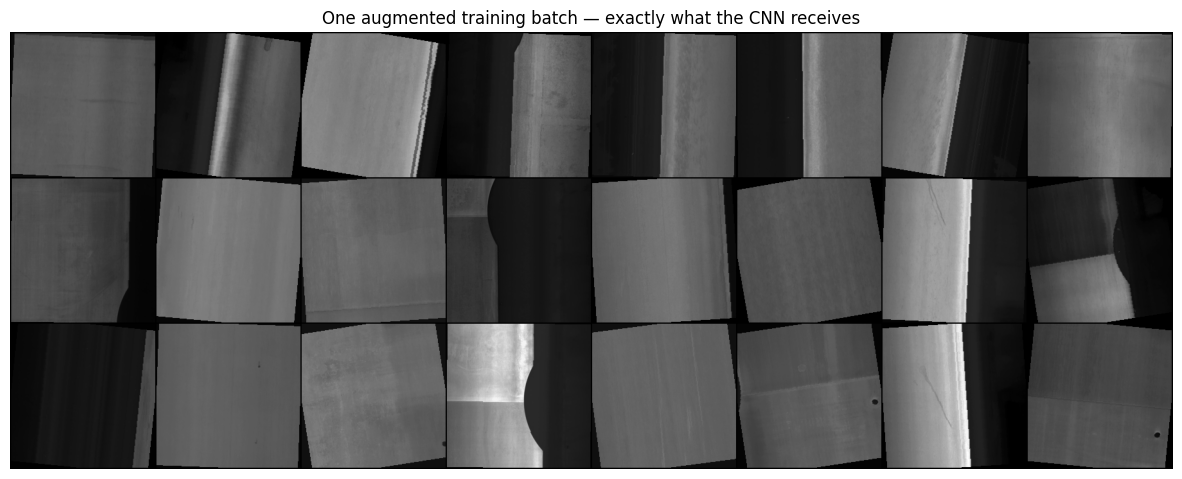

Labels (row by row):
  welding_line  | water_spot    | water_spot    | crescent_gap  | silk_spot     | silk_spot     | silk_spot     | punching_hole
  crescent_gap  | water_spot    | welding_line  | crescent_gap  | silk_spot     | punching_hole | water_spot    | welding_line 
  silk_spot     | inclusion     | punching_hole | welding_line  | silk_spot     | welding_line  | water_spot    | punching_hole


In [11]:
def denormalize(t):
    return t * 0.5 + 0.5

grid = make_grid(denormalize(images[:24]), nrow=8, padding=2)
plt.figure(figsize=(15, 6))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray')
plt.axis('off')
plt.title("One augmented training batch — exactly what the CNN receives")
plt.show()

print("Labels (row by row):")
for r in range(3):
    row = [class_names[labels[r * 8 + c]][:13] for c in range(8)]
    print("  " + " | ".join(f"{n:<13s}" for n in row))

## Step 12 — CNN Theory: The Three Core Operations + Two Modern Tools

Before building the model, let's recall exactly what each layer does. A CNN block = **Convolution → Activation → Pooling**, repeated.

---

### 12.1 Convolution (`nn.Conv2d`) — *the feature extractor*

A small matrix of learnable weights (a **kernel**, e.g. 3×3) slides across the image. At each position it computes a weighted sum (dot product) of the pixels beneath it:

```
Input patch        Kernel             Output
[ 10  20  30 ]   [ -1  0  1 ]
[ 10  20  30 ] ⊛ [ -1  0  1 ]  =  (30-10)+(30-10)+(30-10) = 60   ← strong vertical edge!
[ 10  20  30 ]   [ -1  0  1 ]
```

- Early kernels learn **edges and lines**; deeper kernels compose them into **textures and shapes** — exactly what separates a *silk spot* from a *water spot*.
- `out_channels=32` means 32 different kernels → 32 output **feature maps**, each highlighting a different pattern.
- `padding=1` with a 3×3 kernel keeps the height/width unchanged.
- Parameters = `(3 × 3 × in_channels + 1 bias) × out_channels` — tiny, thanks to **weight sharing**: the same kernel is reused at every image position.
- We stack **two 3×3 convolutions per block**: together they see a 5×5 region but with fewer parameters and more non-linearity than a single 5×5 kernel.

---

### 12.2  Activation (`nn.ReLU`) — *the non-linearity*

`ReLU(x) = max(0, x)` — negatives become 0, positives pass through. Without it, stacked convolutions collapse mathematically into **one single linear map** (linear ∘ linear = linear) — depth would add nothing. ReLU is cheap and avoids the vanishing gradients of sigmoid/tanh.

---

### 12.3  Pooling (`nn.MaxPool2d`) — *the summarizer*

A 2×2 window slides over the feature map keeping only the **maximum**:

```
[ 1  3 | 2  0 ]
[ 5  2 | 1  4 ]        [ 5  4 ]
 ------+------    →    [ 8  6 ]
[ 8  1 | 6  2 ]
[ 4  7 | 3  5 ]
```

1. Halves height and width → 4× fewer values → faster, fewer parameters downstream.
2. Gives **translation invariance** — the network asks *"is the feature present?"*, not *"at which exact pixel?"*.
3. Has **zero** learnable parameters.

---

### 12.4  BatchNorm (`nn.BatchNorm2d`) — *the training stabilizer*

After each convolution, BatchNorm re-standardizes every channel across the batch (mean 0, variance 1, plus a learnable scale and shift). Each layer then receives consistently-scaled inputs, which makes training **much faster and more stable**, and adds mild regularization. The modern standard block is **Conv → BN → ReLU**.

---

### 12.5  Global Average Pooling (GAP) — *the parameter-efficient classifier head*

Flattening the final feature maps into a huge `Linear` layer would create millions of parameters in a single layer — a recipe for overfitting on a small dataset. **GAP** instead averages each feature map down to a **single number**: `[B, 256, 14, 14] → [B, 256]`, so the classifier is just `Linear(256 → 6)`.

Intuition: each of the 256 channels acts as a *"defect-pattern detector"*, and GAP asks *"how strongly does this pattern appear anywhere in the image?"* — position-independent, which is exactly right for defect classification.

> **One PyTorch convention to remember:** the model outputs raw scores (**logits**), with **no softmax layer**. `nn.CrossEntropyLoss` applies `log_softmax` internally (numerically more stable). We apply softmax manually only when we want human-readable probabilities at prediction time.

## Step 13 — Build the CNN (`nn.Module`)

**What we are doing:** Defining the network as a class inheriting from `nn.Module` — the standard PyTorch pattern: layers are declared in `__init__` (this is where the parameters get created), and `forward(x)` defines how data flows through them (autograd records this graph and derives the backward pass automatically). A helper function builds one reusable block = **(Conv → BN → ReLU) ×2 → MaxPool**.

**Why this architecture:**

```
Input [B, 1, 224, 224]
  ├─ BLOCK 1: (Conv 1→32,   BN, ReLU) ×2 → MaxPool   [B,  32, 112, 112]
  ├─ BLOCK 2: (Conv 32→64,  BN, ReLU) ×2 → MaxPool   [B,  64,  56,  56]
  ├─ BLOCK 3: (Conv 64→128, BN, ReLU) ×2 → MaxPool   [B, 128,  28,  28]
  ├─ BLOCK 4: (Conv 128→256,BN, ReLU) ×2 → MaxPool   [B, 256,  14,  14]
  ├─ Global Average Pooling                           [B, 256]
  ├─ Dropout(0.3)
  └─ Linear(256 → 6)  →  logits                       [B, 6]
```

- The classic design pattern: **spatial size shrinks** (224→112→56→28→14) while the **number of channels grows** (32→64→128→256) — we trade *"where"* information for *"what"* information.
- Four blocks give enough depth to build the edge → texture → shape hierarchy.
- The GAP head keeps the total parameter count around one million — small enough to train well on ~1,300 training images.
- `Dropout(0.3)` randomly zeroes 30 % of the pooled features during training, preventing co-adaptation (extra overfitting protection).

In [12]:
def conv_block(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2),
    )

class DefectCNN(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.block1 = conv_block(1, 32)
        self.block2 = conv_block(32, 64)
        self.block3 = conv_block(64, 128)
        self.block4 = conv_block(128, 256)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        return self.head(x)

model = DefectCNN(num_classes=NUM_CLASSES).to(device)
print(model)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

DefectCNN(
  (block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block4): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride

## Step 14 — Sanity Check: Trace the Shapes Through the Network

**What we are doing:** Pushing one dummy image through each block and printing the tensor shape after every stage.

**Why we are doing it:** Verifying the shapes *before* training catches dimension-mismatch bugs early, when they are easy to fix — instead of as cryptic runtime errors in the middle of a training run. You should see exactly the shapes from the architecture diagram: 224 → 112 → 56 → 28 → 14, channels 32 → 64 → 128 → 256, ending in 6 logits.

In [13]:
x = torch.randn(1, 1, IMG_SIZE, IMG_SIZE).to(device)
print(f"Input          : {tuple(x.shape)}")
x = model.block1(x)
print(f"After Block 1  : {tuple(x.shape)}")
x = model.block2(x)
print(f"After Block 2  : {tuple(x.shape)}")
x = model.block3(x)
print(f"After Block 3  : {tuple(x.shape)}")
x = model.block4(x)
print(f"After Block 4  : {tuple(x.shape)}")
x = model.head(x)
print(f"Output logits  : {tuple(x.shape)}")

Input          : (1, 1, 224, 224)
After Block 1  : (1, 32, 112, 112)
After Block 2  : (1, 64, 56, 56)
After Block 3  : (1, 128, 28, 28)
After Block 4  : (1, 256, 14, 14)
Output logits  : (1, 6)


## Step 15 — Loss with Class Weights, Optimizer, and LR Schedule

**What we are doing:** Computing per-class weights from the **training split only**, then creating the loss function, optimizer, and learning-rate scheduler.

**Why each piece:**

1. **Class-weighted loss.** The largest class has ~3× more images than the smallest, so it would dominate the gradients and the model would favor it. We weight each class **inversely to its frequency** — `weight_c = N_total / (num_classes × N_c)` — so a mistake on a rare class costs proportionally more. This improves recall on the smaller classes. Weights are computed from the training split only: statistics must never be taken from validation/test data.

2. **Label smoothing (0.1).** Instead of demanding probability 1.0 for the true class, the target becomes 0.9 with the remainder spread over the other classes. The model stops becoming over-confident, generalizes better, and tolerates the occasional mislabeled image that every industrial dataset contains.

3. **AdamW optimizer (lr = 10⁻³, weight decay = 10⁻⁴).** Adam adapts a learning rate per parameter using running averages of the gradients; the *W* variant applies weight decay correctly (proper L2 regularization).

4. **Cosine annealing schedule.** The learning rate starts at 10⁻³ and decays smoothly along a cosine curve to ≈ 0 over the training run: big exploratory steps early, tiny refining steps late — and no manual guessing about when to drop the LR.

In [14]:
train_labels = all_labels[train_idx]
class_freq = np.bincount(train_labels, minlength=NUM_CLASSES)
class_weights = len(train_labels) / (NUM_CLASSES * class_freq)
weights_t = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class weights (rare classes get larger weight):")
for c, w, n in zip(class_names, class_weights, class_freq):
    print(f"  {c:<15s} n_train={n:<4d} weight={w:.3f}")

criterion = nn.CrossEntropyLoss(weight=weights_t, label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

EPOCHS = 10
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print("\nLoss, optimizer and scheduler ready")

Class weights (rare classes get larger weight):
  crescent_gap    n_train=158  weight=1.383
  inclusion       n_train=151  weight=1.447
  punching_hole   n_train=154  weight=1.419
  silk_spot       n_train=455  weight=0.480
  water_spot      n_train=202  weight=1.082
  welding_line    n_train=191  weight=1.144

Loss, optimizer and scheduler ready


## Step 16 — The Training Loop

**What we are doing:** Training for up to 40 epochs. Each epoch has two phases:
- **Training phase** — for every batch, the five sacred lines of PyTorch run:
  1. `optimizer.zero_grad()` — clear old gradients (they accumulate by default!)
  2. `outputs = model(images)` — **forward** pass → logits
  3. `loss = criterion(outputs, labels)` — compute the weighted, label-smoothed loss
  4. `loss.backward()` — **backward** pass: autograd fills the gradient of every parameter
  5. `optimizer.step()` — update the weights
- **Validation phase** — score the whole validation set with no weight updates.

After each epoch the scheduler decays the LR, and we apply **early stopping**: whenever validation accuracy improves we save the weights as the best checkpoint; if it fails to improve for 10 consecutive epochs we stop, and at the end we restore the best checkpoint.

**Why the mode switches matter:** `model.train()` enables Dropout and lets BatchNorm use batch statistics; `model.eval()` disables Dropout and switches BatchNorm to its running statistics. Validation additionally runs inside `torch.no_grad()` — no gradient tracking → faster, less memory, and an honest evaluation. Forgetting these switches is one of the most common PyTorch bugs.

> ⏱ Expect roughly 25–35 s per epoch on a Colab T4 → about 15–20 minutes total.

In [ ]:
PATIENCE = 10
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}
best_val_acc = 0.0
epochs_no_improve = 0

for epoch in range(1, EPOCHS + 1):

    model.train()
    running_loss, correct, seen = 0.0, 0, 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == lbls).sum().item()
        seen += lbls.size(0)
    train_loss, train_acc = running_loss / seen, correct / seen

    model.eval()
    running_loss, correct, seen = 0.0, 0, 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            outputs = model(imgs)
            running_loss += criterion(outputs, lbls).item() * imgs.size(0)
            correct += (outputs.argmax(1) == lbls).sum().item()
            seen += lbls.size(0)
    val_loss, val_acc = running_loss / seen, correct / seen

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(optimizer.param_groups[0]["lr"])
    scheduler.step()

    marker = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_defect_cnn.pt")
        epochs_no_improve = 0
        marker = "  <- best, saved"
    else:
        epochs_no_improve += 1

    print(f"Epoch {epoch:2d}/{EPOCHS} | lr {history['lr'][-1]:.5f} | "
          f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
          f"val loss {val_loss:.4f} acc {val_acc:.4f}{marker}")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping: no val-accuracy improvement for {PATIENCE} epochs.")
        break

model.load_state_dict(torch.load("best_defect_cnn.pt"))
print(f"\nBest validation accuracy: {best_val_acc:.4f} — weights restored")

Epoch  1/10 | lr 0.00100 | train loss 1.7102 acc 0.2586 | val loss 1.7070 acc 0.2705  <- best, saved


## Step 17 — Learning Curves and the LR Schedule

**What we are doing:** Plotting training vs validation **accuracy**, training vs validation **loss**, and the **learning rate** across the epochs.

**Why we are doing it:** The curves diagnose the health of the training at a glance:

| Pattern | Diagnosis | Fix |
|---------|-----------|-----|
| Both curves improve together, small gap |  Healthy fit | Train longer if still rising |
| Train ↑ but validation flat/↓ (diverging) |  **Overfitting** — memorizing | More augmentation / dropout / data |
| Both stuck at low accuracy |  **Underfitting** — model too weak | Bigger model / longer training |

Because augmentation and dropout are active **only** during training, training accuracy can even sit slightly below validation accuracy — that is perfectly normal. The third panel shows the cosine decay of the learning rate; connect the shrinking LR with the smoothing of the curves late in training.

In [ ]:
ep = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))

axes[0].plot(ep, history["train_acc"], 'o-', label='Train')
axes[0].plot(ep, history["val_acc"], 's-', label='Validation')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(ep, history["train_loss"], 'o-', label='Train')
axes[1].plot(ep, history["val_loss"], 's-', label='Validation')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(ep, history["lr"], 'o-', color='purple')
axes[2].set_title('Learning Rate (cosine schedule)')
axes[2].set_xlabel('Epoch')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best validation accuracy: {max(history['val_acc']):.4f} "
      f"(epoch {int(np.argmax(history['val_acc'])) + 1})")

## Step 18 — Final Evaluation on the Test Set

**What we are doing:** Scoring the best checkpoint on the **held-out test set** and collecting every individual prediction for the confusion matrix in the next step.

**Why we are doing it:** The test set was never seen during training *or* model selection, so this is the honest, unbiased number — our proxy for "brand-new photos from the factory floor tomorrow". Validation accuracy is slightly optimistic because we used it to choose the best checkpoint; that is exactly why the test set exists and is touched only once.

In [ ]:
model.eval()
y_true, y_pred = [], []
correct, seen = 0, 0
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        preds = model(imgs).argmax(1)
        correct += (preds == lbls).sum().item()
        seen += lbls.size(0)
        y_true.extend(lbls.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

y_true, y_pred = np.array(y_true), np.array(y_pred)
test_acc = correct / seen
print(f"Test accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"(Random guessing over {NUM_CLASSES} classes = {100/NUM_CLASSES:.1f}%)")

## Step 19 — Confusion Matrix (Raw Counts + Row-Normalized)

**What we are doing:** Plotting the confusion matrix twice, side by side: with **raw counts** and **row-normalized** (each row divided by its total, so the diagonal shows the **per-class recall**). We also automatically print the single most-confused class pair.

**Why we are doing it:** Rows = true class, columns = predicted class, so cell *(i, j)* counts test images of class *i* that the model called class *j*. A single accuracy number hides *which* classes fail; the confusion matrix reveals it. The normalized view is the fair one under class imbalance — a large class would otherwise visually dominate. Now check the intuition from Step 7: do the texturally similar classes (silk_spot vs water_spot) confuse the model, while the shape-distinct ones (punching_hole) score cleanly?

In [ ]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Confusion Matrix — Raw Counts')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=35)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Row-Normalized (diagonal = recall)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()

cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
i, j = np.unravel_index(cm_off.argmax(), cm_off.shape)
print(f"Most confused pair: TRUE '{class_names[i]}' predicted as '{class_names[j]}' ({cm_off[i, j]} times)")

## Step 20 — Per-Class Precision, Recall, and F1

**What we are doing:** Printing the full classification report with per-class metrics.

**Why we are doing it — the definitions:**
- **Precision** = of all images *predicted* as this class, how many really were? (low precision → false alarms)
- **Recall** = of all images that *truly are* this class, how many did we catch? (low recall → missed defects)
- **F1** = harmonic mean of the two.

**Industrial insight:** in quality control, **recall usually matters more** — shipping a defective metal sheet is far costlier than double-checking a good one. Thanks to the class-weighted loss, the smaller classes should hold reasonable recall despite having fewer training images.

In [ ]:
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

## Step 21 — Visualize Predictions on Test Images

**What we are doing:** Showing ten test images with the model's predicted class, its **confidence** (the softmax probability — applied manually here, since the model outputs raw logits), and the true label. Correct predictions are titled in green, mistakes in red.

**Why we are doing it:** Aggregate metrics hide the interesting failures. Inspecting individual mistakes often reveals ambiguous photos, images containing two defects at once, extreme lighting, or even mislabeled images in the dataset — insight no summary number can give.

In [ ]:
model.eval()
imgs, lbls = next(iter(test_loader))
with torch.no_grad():
    probs = torch.softmax(model(imgs.to(device)), dim=1).cpu()
preds = probs.argmax(1)

plt.figure(figsize=(16, 6))
for i in range(min(10, len(imgs))):
    plt.subplot(2, 5, i + 1)
    plt.imshow(denormalize(imgs[i]).squeeze(), cmap='gray')
    color = 'green' if preds[i] == lbls[i] else 'red'
    plt.title(f"pred: {class_names[preds[i]]} ({probs[i, preds[i]]*100:.0f}%)\n"
              f"true: {class_names[lbls[i]]}", fontsize=8, color=color)
    plt.axis('off')
plt.suptitle("Predictions on Test Images (green = correct, red = wrong)")
plt.tight_layout()
plt.show()

## Step 22 — Looking Inside the CNN: Feature Map Visualization

**What we are doing:** Registering **forward hooks** on the four convolution blocks (the idiomatic PyTorch way to capture intermediate activations), pushing one test image through the network, and displaying 8 feature maps from each block. Hooks are removed afterwards.

**Why we are doing it:** This is the visual proof of the CNN hierarchy we described in the theory step. Watch the progression:
- **Block 1** maps look like edge-filtered versions of the input — bright along lines and boundaries.
- **Blocks 2–3** respond to textures and combinations of edges.
- **Block 4** maps are small (14×14) and abstract — often just a few bright blobs marking *"defect evidence is roughly here"*.

All of this — edges → textures → defect evidence — was learned automatically from data, with no hand-engineered features.

In [ ]:
activations = {}

def get_hook(name):
    def hook(module, inp, out):
        activations[name] = out.detach().cpu()
    return hook

hooks = [getattr(model, f"block{b}").register_forward_hook(get_hook(f"Block {b}"))
         for b in (1, 2, 3, 4)]

img = imgs[0:1].to(device)
with torch.no_grad():
    _ = model(img)
for h in hooks:
    h.remove()

plt.figure(figsize=(15, 9))
plt.subplot(5, 9, 1)
plt.imshow(denormalize(imgs[0]).squeeze(), cmap='gray')
plt.title(f"Input\n({class_names[lbls[0]]})", fontsize=8)
plt.axis('off')

for b in range(1, 5):
    act = activations[f"Block {b}"][0]
    for f in range(8):
        plt.subplot(5, 9, b * 9 + f + 2)
        plt.imshow(act[f], cmap='viridis')
        plt.title(f"B{b} map {f}", fontsize=7)
        plt.axis('off')
plt.suptitle("Feature maps: edges → textures → abstract defect evidence")
plt.tight_layout()
plt.show()

for b in range(1, 5):
    print(f"Block {b} activation shape: {tuple(activations[f'Block {b}'].shape)}")

## Step 23 — Save and Reload the Model

**What we are doing:** The best weights were already saved during training as `best_defect_cnn.pt`. Here we prove the round-trip works: create a brand-new model instance, load the saved `state_dict` into it, and re-check the test accuracy — it must match Step 18 exactly.

**Why we are doing it:** Saving the `state_dict` (weights only) is the recommended PyTorch practice — at load time you recreate the architecture from the class definition and fill in the weights. Verifying the reload guarantees the checkpoint is usable in a future session or deployment.

>Colab storage is temporary — download `best_defect_cnn.pt` from the file browser before the runtime disconnects!

In [ ]:
reloaded = DefectCNN(num_classes=NUM_CLASSES).to(device)
reloaded.load_state_dict(torch.load("best_defect_cnn.pt"))
reloaded.eval()

correct, seen = 0, 0
with torch.no_grad():
    for imgs_b, lbls_b in test_loader:
        out = reloaded(imgs_b.to(device))
        correct += (out.argmax(1).cpu() == lbls_b).sum().item()
        seen += lbls_b.size(0)

print(f"Reloaded model test accuracy: {correct/seen:.4f}")
print("Model file:", os.path.abspath('best_defect_cnn.pt'))

---

##  Session Recap

| Concept | Where we used it |
|---------|------------------|
| **Data curation** | Selected the 6 classes with enough images to be learnable |
| **Convolution** | Two stacked 3×3 `nn.Conv2d` per block, extracting edges → textures → defect shapes |
| **Activation (ReLU)** | After every convolution — the essential non-linearity |
| **Pooling** | `nn.MaxPool2d(2)` after every block — 224→112→56→28→14 + translation invariance |
| **BatchNorm** | After every convolution — fast, stable training |
| **Global Average Pooling** | Parameter-efficient, position-independent classifier head |
| **Dropout** | 30 % on the pooled features — overfitting protection |
| **Class-weighted loss + label smoothing** | Fair learning under class imbalance, better calibration |
| **AdamW + cosine LR schedule** | Adaptive optimization with a principled learning-rate decay |
| **The 5-line training step** | `zero_grad → forward → loss → backward → step` |
| **train()/eval() modes** | Dropout and BatchNorm behave differently in training vs evaluation |
| **Early stopping** | Best-checkpoint tracking on validation accuracy |
| **Evaluation** | Test accuracy, confusion matrix (raw + normalized), precision/recall/F1 |
| **Interpretability** | Feature maps captured with forward hooks |

##  Exercises (try these yourself!)

1. **Easy:** Set `N_KEEP = 8` in Step 4. How does accuracy change when the two smaller classes join, and why?
2. **Easy:** Remove `label_smoothing=0.1` and retrain. Do the prediction confidences in Step 21 become more extreme?
3. **Medium:** Remove the class weights from the loss and compare the *normalized* confusion matrix diagonals — which classes lose recall?
4. **Medium:** Change `IMG_SIZE` to 128. How much accuracy is lost, and what does that tell you about resolution vs texture detail?
5. **Medium:** Replace `CosineAnnealingLR` with `OneCycleLR`. Does training converge faster?
6. **Hard:** Add test-time augmentation: average the softmax outputs of each test image and its horizontal/vertical flips. Does test accuracy improve?
7. **Hard:** The `label/` folder contains XML bounding boxes. Crop the defect regions and train on the crops. Does localized training beat whole-image training?

---
*End of session. You built a complete, end-to-end CNN pipeline: curate → load → augment → train → evaluate → interpret.*